In [1]:
import os
import numpy as np

In [2]:
os.listdir()

['General ES Vol AutoCorr.ipynb', '.ipynb_checkpoints']

In [3]:
es_path = "../data/parquet/es"

os.listdir(es_path)

['ES_c_0_bbo-1s_2025-11-01_2026-09-12.parquet',
 'ES_c_0_bbo-1s_2022-11-01_2023-11-01.parquet',
 'pull_es_bbo.log',
 'yahoo_ESF_1m_20260912.parquet',
 'ES_c_0_bbo-1s_2023-11-01_2024-11-01.parquet',
 'ES_c_0_bbo-1s_2024-11-01_2025-11-01.parquet',
 'databento_ledger.json',
 'ES_c_0_bbo-1s_2021-11-01_2022-11-01.parquet']

In [4]:
import pyarrow.parquet as pq

In [5]:
file = pq.ParquetFile(os.path.join(es_path, 'ES_c_0_bbo-1s_2021-11-01_2022-11-01.parquet'))

In [6]:
n_rows = file.metadata.num_rows

n_rows

18763087

In [7]:
start = 0

for i in range(file.num_row_groups):
    n = file.metadata.row_group(i).num_rows
    end = start + n

    print(f"Row group {i}: rows {start} to {end - 1}")

    start = end
    

Row group 0: rows 0 to 1048575
Row group 1: rows 1048576 to 2097151
Row group 2: rows 2097152 to 3145727
Row group 3: rows 3145728 to 4194303
Row group 4: rows 4194304 to 5242879
Row group 5: rows 5242880 to 6291455
Row group 6: rows 6291456 to 7340031
Row group 7: rows 7340032 to 8388607
Row group 8: rows 8388608 to 9437183
Row group 9: rows 9437184 to 10485759
Row group 10: rows 10485760 to 11534335
Row group 11: rows 11534336 to 12582911
Row group 12: rows 12582912 to 13631487
Row group 13: rows 13631488 to 14680063
Row group 14: rows 14680064 to 15728639
Row group 15: rows 15728640 to 16777215
Row group 16: rows 16777216 to 17825791
Row group 17: rows 17825792 to 18763086


In [8]:
test_df = file.read_row_group(0)

In [9]:
test_df

pyarrow.Table
ts_event: timestamp[ns, tz=UTC]
rtype: uint8
publisher_id: uint16
instrument_id: uint32
side: large_string
price: double
size: uint32
flags: uint8
sequence: uint32
bid_px_00: double
ask_px_00: double
bid_sz_00: uint32
ask_sz_00: uint32
bid_ct_00: uint32
ask_ct_00: uint32
symbol: large_string
ts_recv: timestamp[ns, tz=UTC]
----
ts_event: [[2021-10-31 23:59:57.316485115Z,2021-11-01 00:00:00.850263355Z,2021-11-01 00:00:00.850263355Z,2021-11-01 00:00:02.456374851Z,2021-11-01 00:00:02.456374851Z,...,2021-11-22 00:28:02.366193027Z,2021-11-22 00:28:03.806665353Z,2021-11-22 00:28:04.793553409Z,2021-11-22 00:28:05.002510905Z,2021-11-22 00:28:06.120330059Z]]
rtype: [[195,195,195,195,195,...,195,195,195,195,195]]
publisher_id: [[1,1,1,1,1,...,1,1,1,1,1]]
instrument_id: [[8858,8858,8858,8858,8858,...,8858,8858,8858,8858,8858]]
side: [["A","A","A","B","B",...,"A","B","B","B","B"]]
price: [[4610.25,4610.5,4610.5,4610.75,4610.75,...,4701.25,4701.25,4701,4701.25,4701]]
size: [[1,8,8,1,1,

In [10]:
test_df = test_df.to_pandas()

In [11]:
test_df.head()

,ts_event,rtype,publisher_id,instrument_id,side,price,size,flags,sequence,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00,bid_ct_00,ask_ct_00,symbol
ts_recv,,,,,,,,,,,,,,,,
2021-11-01 00:00:00+00:00,2021-10-31 23:59:57.316485115+00:00,195,1,8858,A,4610.25,1,168,186480,4610.25,4610.50,4,17,4,15,ES.c.0
2021-11-01 00:00:01+00:00,2021-11-01 00:00:00.850263355+00:00,195,1,8858,A,4610.50,8,128,186801,4610.50,4610.75,12,26,12,19,ES.c.0
2021-11-01 00:00:02+00:00,2021-11-01 00:00:00.850263355+00:00,195,1,8858,A,4610.50,8,128,186836,4610.50,4610.75,13,19,13,12,ES.c.0
2021-11-01 00:00:03+00:00,2021-11-01 00:00:02.456374851+00:00,195,1,8858,B,4610.75,1,128,186992,4610.50,4610.75,16,13,16,10,ES.c.0
2021-11-01 00:00:04+00:00,2021-11-01 00:00:02.456374851+00:00,195,1,8858,B,4610.75,1,128,187012,4610.50,4610.75,16,14,16,11,ES.c.0


<Axes: xlabel='ts_recv'>

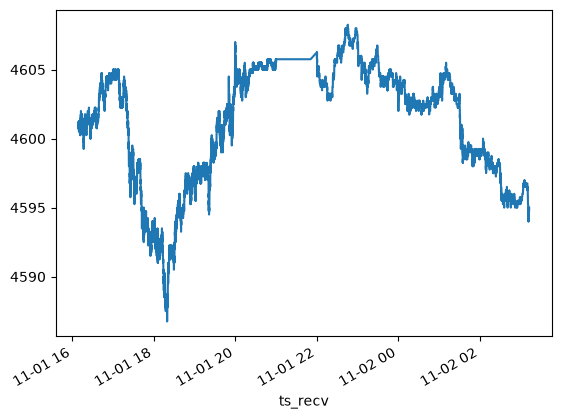

In [12]:
test_df[50000:80000].price.plot()

Note the no trades around 22:00 (UTC). This is a break (21 -> 22) UTC

In [13]:
test_df["swmid"] = (test_df["bid_sz_00"] * test_df["ask_px_00"] + test_df["ask_sz_00"] * test_df["bid_px_00"])/(test_df["bid_sz_00"] + test_df["ask_sz_00"])

In [14]:
test_df["log_ret"] = np.log(test_df["swmid"]).diff()

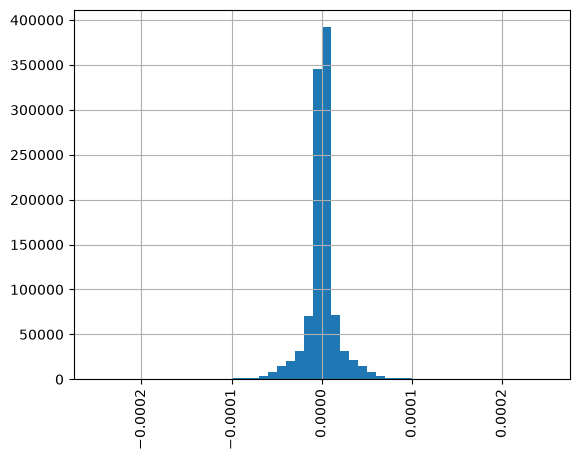

In [15]:
ax = test_df.log_ret.clip(-0.00025, 0.00025).hist(bins=50)
ax.tick_params(axis="x", labelrotation=90)

In [16]:
test_df.log_ret.mean()

np.float64(1.858810214128333e-08)

In [17]:
std = test_df.log_ret.std()

In [18]:
std * np.sqrt(365 * 24 * 60 * 60)

np.float64(0.14328647387067941)

In [19]:
test_df.log_ret.kurt()

np.float64(5190.737931310838)

In [20]:
test_df.log_ret.skew()

np.float64(-15.683563373681329)

## 1 Min Data

In [21]:
import sys; sys.path.insert(0, "/home/joshua/btc"); import os; os.chdir("/home/joshua/btc")
from data_collection.es_futures import load_bbo, iter_bbo

In [22]:
import sys; sys.path.insert(0, "/home/joshua/btc"); import os; os.chdir("/home/joshua/btc")

In [23]:
df = load_bbo(freq = "60s")

In [24]:
df["swmid"] = (df["bid_sz_00"] * df["ask_px_00"] + df["ask_sz_00"] * df["bid_px_00"])/(df["bid_sz_00"] + df["ask_sz_00"])

In [25]:
df["log_ret"] = np.log(df.swmid).diff()

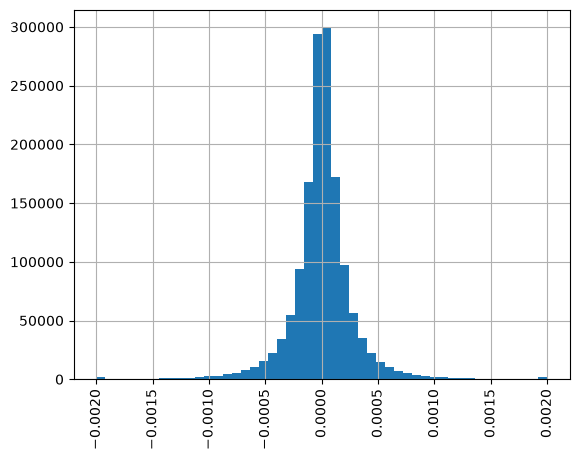

In [26]:
P = 0.002
ax = df.log_ret.clip(-P, P).hist(bins=50)
ax.tick_params(axis="x", labelrotation=90)

In [27]:
df.log_ret.skew()

np.float64(0.5639530743435983)

In [28]:
df.log_ret.kurt()

np.float64(314.229912678964)

## Return moments across timeframes — mid vs size-weighted mid

For each sampling frequency: load the sampled book state on that grid (`load_bbo(freq=...)`), compute both the plain
mid `(bid+ask)/2` and the size-weighted mid (`swmid`, microprice), and take log returns of each.
Only **consecutive** grid points are used — a return is dropped if the gap to the previous row isn't exactly `freq`
(session break, weekend, holiday) or if the contract rolled. Annualisation uses the empirical number of periods per
year in the data (n returns / years spanned), i.e. per *trading* time — which is why the annualised **mean** grows
with the horizon (short horizons exclude every overnight/weekend move, long ones keep more of them) while
variance/vol stay flat. Kurtosis is excess (pandas `kurt`). The mid is quantised to half-ticks (0.125), so at short
horizons most mid returns are exactly 0 or ±1 half-tick; the swmid moves continuously with queue sizes.

In [29]:
import pandas as pd
from scipy import stats

FREQS = ["30s", "60s", "2min", "5min", "15min", "30min", "1h", "4h", "1D"]
PRICES = ["mid", "swmid"]
COLS = ["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00", "instrument_id"]

def returns_at(freq):
    """{'mid': log returns, 'swmid': log returns} on the freq grid, consecutive rows only, no rolls."""
    d = load_bbo(freq=freq, columns=COLS)
    px = {"mid": (d.bid_px_00 + d.ask_px_00) / 2,
          "swmid": (d.bid_sz_00 * d.ask_px_00 + d.ask_sz_00 * d.bid_px_00) / (d.bid_sz_00 + d.ask_sz_00)}
    keep = (d.index.to_series().diff() == pd.Timedelta(freq)) & ~d.roll
    return {k: np.log(v).diff()[keep].dropna() for k, v in px.items()}

def moments(r, freq, price):
    years = (r.index[-1] - r.index[0]).total_seconds() / (365.25 * 86400)
    ppy = len(r) / years                      # periods per year, empirical
    return {"price": price, "freq": freq, "n": len(r), "periods/yr": round(ppy),
            "mean (ann.)": r.mean() * ppy, "variance (ann.)": r.var() * ppy, "vol (ann.)": r.std() * np.sqrt(ppy),
            "skew": r.skew(), "excess kurtosis": r.kurt(), "zero returns": (r == 0).mean()}

rets = {f: returns_at(f) for f in FREQS}
table = (pd.DataFrame([moments(rets[f][p], f, p) for f in FREQS for p in PRICES])
           .set_index(["freq", "price"]))
table.style.format({"mean (ann.)": "{:+.4f}", "variance (ann.)": "{:.5f}", "vol (ann.)": "{:.4f}",
                    "skew": "{:+.2f}", "excess kurtosis": "{:.1f}", "n": "{:,}", "zero returns": "{:.1%}"})

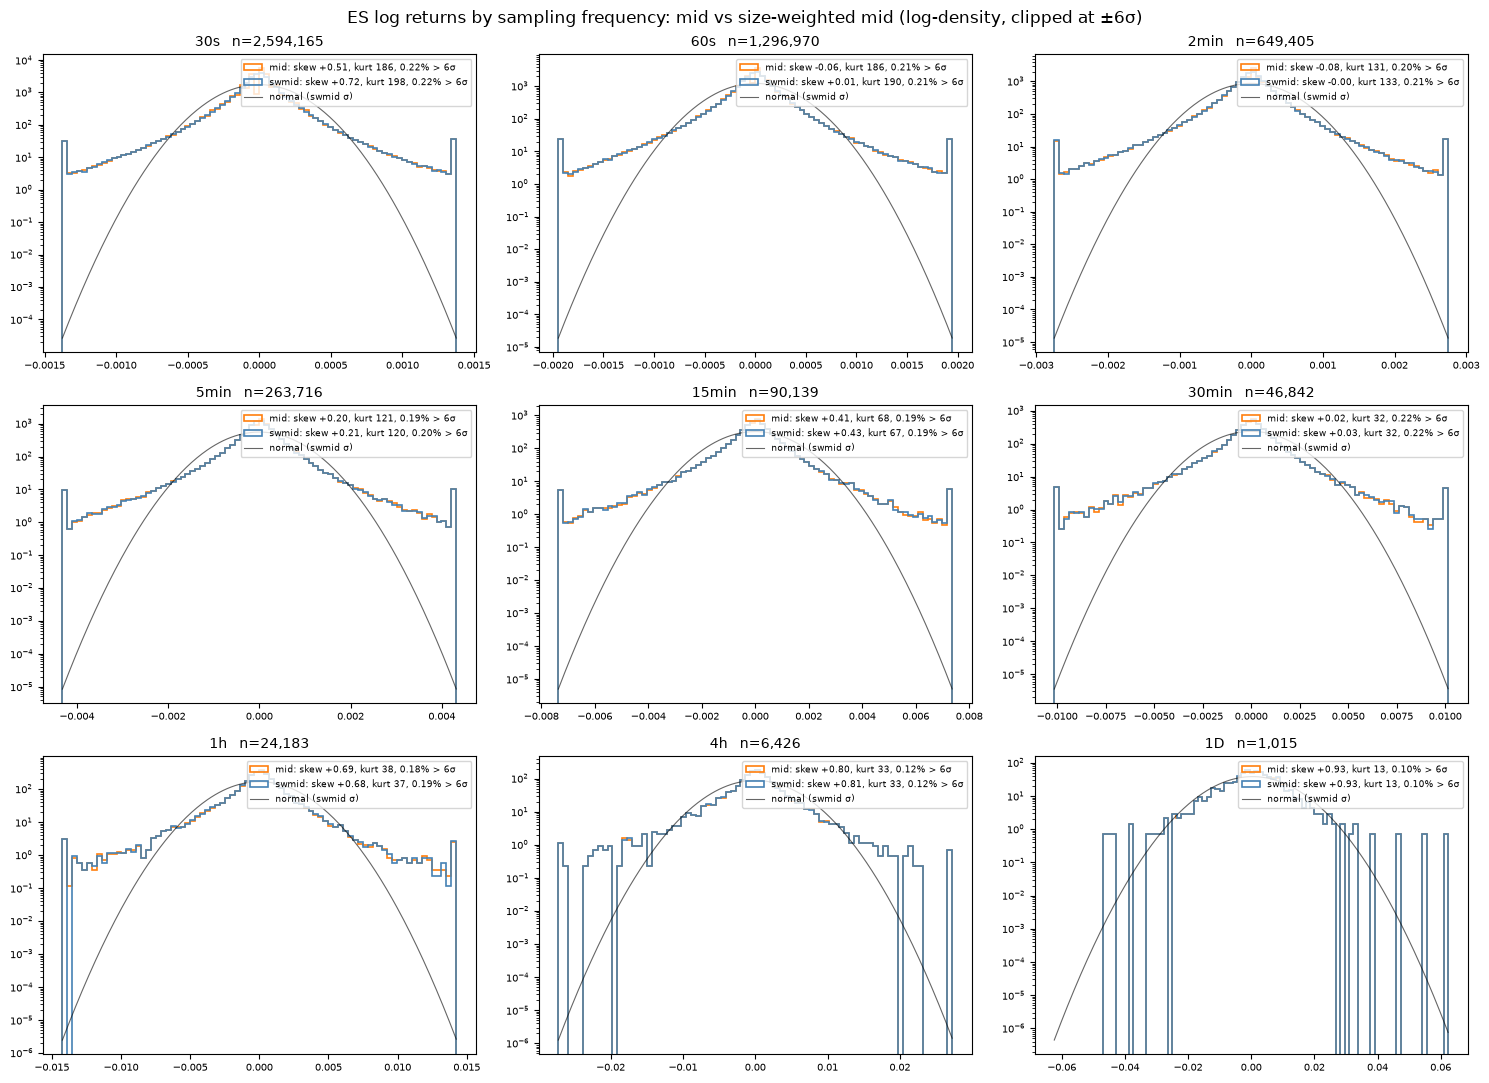

In [30]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, f in zip(axes.flat, FREQS):
    clip = 6 * rets[f]["swmid"].std()         # same window for both series; tails beyond ±6σ are clipped in
    x = np.linspace(-clip, clip, 300)
    for p, colour in (("mid", "tab:orange"), ("swmid", "steelblue")):
        r = rets[f][p]
        ax.hist(r.clip(-clip, clip), bins=80, density=True, histtype="step", lw=1.2, color=colour,
                label=f"{p}: skew {r.skew():+.2f}, kurt {r.kurt():.0f}, {(r.abs() > clip).mean():.2%} > 6σ")
    ax.plot(x, stats.norm.pdf(x, rets[f]["swmid"].mean(), rets[f]["swmid"].std()), color="k", lw=0.8, alpha=0.6, label="normal (swmid σ)")
    ax.set_title(f"{f}   n={len(rets[f]['swmid']):,}", fontsize=10)
    ax.set_yscale("log"); ax.tick_params(labelsize=7); ax.legend(fontsize=6.5, loc="upper right")
fig.suptitle("ES log returns by sampling frequency: mid vs size-weighted mid (log-density, clipped at ±6σ)")
fig.tight_layout()

## Realised variance per minute from the 1-second book (streamed once, cached)

Everything below works off a **per-minute realised variance** series built from the 1s size-weighted mid:
`rv = Σ (Δ log swmid)²` over the returns landing in each minute (returns between consecutive rows, gap ≤ 2 min,
same contract — `bbo-1s` omits seconds with no book change, so a 3 s gap is just a 3 s return). This is far more
informative per minute than one sampled 1-min return, and it is how the intraday profile and the vol-of-vol
models are estimated in the RV literature.

**Memory:** the 1s data is ~89M rows / 1.7 GB on disk. `iter_bbo` yields 2M-row batches (~100 MB), each is
reduced to its per-minute sums and dropped; the last row is carried into the next batch so no return is lost.
The result (~1.7M minutes × 3 columns) is cached in `data/derived/` — first run ≈ 1–3 min, after that instant.

In [ ]:
import time
from pathlib import Path
from data_collection.es_futures import iter_bbo

RV_PATH = Path("data/derived/es_rv_1min.parquet")
COLS = ["bid_px_00", "ask_px_00", "bid_sz_00", "ask_sz_00", "instrument_id"]

def build_rv_1min(start=None, end=None, batch_rows=2_000_000, max_gap="120s"):
    '''One pass over the 1s BBO. Per UTC minute: rv (sum of squared swmid log-returns between consecutive
    rows with gap <= max_gap, same contract, previous quote not inside the 17:00-18:00 ET break), n (returns summed), moves (of which mid changed).
    Only one batch is materialised at a time.'''
    max_gap_ns = int(pd.Timedelta(max_gap).value)
    parts, carry = [], None
    for b in iter_bbo(start, end, columns=COLS, batch_rows=batch_rows):
        b = b.sort_index()
        if carry is not None:
            b = pd.concat([carry, b])
        px = ((b.bid_sz_00 * b.ask_px_00 + b.ask_sz_00 * b.bid_px_00) / (b.bid_sz_00 + b.ask_sz_00)).to_numpy()
        mid = ((b.bid_px_00 + b.ask_px_00) / 2).to_numpy()
        ts, inst = b.index.asi8, b.instrument_id.to_numpy()
        r = np.diff(np.log(px))
        prev_et_hour = pd.to_datetime(ts[:-1], utc=True).tz_convert("America/New_York").hour.to_numpy()
        ok = (np.diff(ts) <= max_gap_ns) & (inst[1:] == inst[:-1]) & np.isfinite(r) & (prev_et_hour != 17)   # no returns *from* the 17:00-18:00 ET break
        g = pd.DataFrame({"minute": ts[1:] // 60_000_000_000,
                          "rv": np.where(ok, r * r, 0.0), "n": ok,
                          "moves": ok & (np.diff(mid) != 0)}).groupby("minute").sum()
        parts.append(g)
        carry = b.iloc[-1:]
    rv = pd.concat(parts).groupby(level=0).sum()              # a minute can straddle two batches
    rv.index = pd.to_datetime(rv.index * 60, unit="s", utc=True).rename("minute")
    return rv

if RV_PATH.exists():
    rv = pd.read_parquet(RV_PATH)
else:
    t = time.perf_counter(); rv = build_rv_1min(); print(f"built in {time.perf_counter() - t:.0f}s")
    RV_PATH.parent.mkdir(parents=True, exist_ok=True); rv.to_parquet(RV_PATH)
rv = rv[rv.n > 0].copy()
print(f"{len(rv):,} minutes, {rv.index[0]} -> {rv.index[-1]}, {rv.n.sum():,.0f} 1s returns, "
      f"annualised vol {np.sqrt(rv.rv.sum() / ((rv.index[-1] - rv.index[0]).total_seconds() / (365.25 * 86400))):.4f}")
rv.describe().T

## Vol by time of day

Clock is **US Eastern** (`America/New_York`) so the US events line up across DST; CME's own clock is Central
(one hour earlier: the 16:00–17:00 CT maintenance break is 17:00–18:00 ET). The x-axis runs in session order
from the 18:00 ET Globex open. Per-minute variance is annualised as if every minute of a 23 h × 252 day year
looked like that one: `vol = sqrt(mean rv × 252 × 1380)` — the same trading-time convention as the table above,
so the flat parts of the curve should sit near the ~16.7% found there.

Mean and median are both shown: the mean is what matters for variance budgets, the median is what a "typical"
minute looks like; the gap between them is the event risk at that time of day.

In [ ]:
ET = "America/New_York"
loc = rv.index.tz_convert(ET)
rv["tod"] = loc.hour * 60 + loc.minute                    # minute of day, ET
rv["dow"] = loc.dayofweek                                 # Mon=0 ... Sun=6
# The 17:00-18:00 ET maintenance break still carries a few sparse pre-open indications with absurd
# implied vol (tiny sizes, crossed/wide books). Drop the window; keep 18:00 itself - that is the reopen.
in_break = rv.tod.between(17 * 60, 18 * 60 - 1)
print(f"dropping {in_break.sum():,} minutes ({in_break.mean():.2%}) inside the 17:00-18:00 ET break; "
      f"their mean rv is {rv.rv[in_break].mean() / rv.rv[~in_break].mean():.0f}x a normal minute")
rv = rv[~in_break].copy()
MIN_PER_YR = 252 * 1380                                   # trading minutes per year (23 h Globex day)
ann = lambda v: np.sqrt(v * MIN_PER_YR)                   # per-minute variance -> annualised vol
sess = lambda tod: (tod - 18 * 60) % 1440                 # minutes since the 18:00 ET Globex open
hhmm = lambda m: f"{(m // 60) % 24:02d}:{m % 60:02d}"

EVENTS = {"Globex open": 18 * 60, "Tokyo open (19:00 during US DST)": 20 * 60, "Europe open": 3 * 60,
          "US data 08:30": 8 * 60 + 30, "Cash open": 9 * 60 + 30, "10:00 data": 10 * 60,
          "London close": 11 * 60 + 30, "FOMC 14:00": 14 * 60, "Cash close": 16 * 60, "Break 17:00": 17 * 60}

prof = rv.groupby("tod").rv.agg(["mean", "median", "count"])
prof["vol_mean"], prof["vol_median"] = ann(prof["mean"]), ann(prof["median"])
prof["sess"] = sess(prof.index); prof = prof.sort_values("sess")

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(prof.sess, prof.vol_mean, lw=0.8, color="steelblue", label="mean rv (annualised vol)")
ax.plot(prof.sess, prof.vol_median, lw=0.8, color="tab:orange", label="median rv")
ax.axhline(ann(rv.rv.mean()), color="k", lw=0.6, ls="--", label=f"all-minute mean {ann(rv.rv.mean()):.3f}")
for name, m in EVENTS.items():
    ax.axvline(sess(m), color="grey", lw=0.6, ls=":")
    ax.text(sess(m) + 3, prof.vol_mean.max() * 0.95, name, rotation=90, va="top", fontsize=7, color="dimgrey")
ax.set_yscale("log"); ax.set_xlim(0, 1440)
ticks = np.arange(0, 1441, 60); ax.set_xticks(ticks); ax.set_xticklabels([hhmm(18 * 60 + t) for t in ticks], rotation=90, fontsize=8)
ax.set_ylabel("annualised vol"); ax.set_title("ES realised vol by minute of day (ET), session order from the 18:00 Globex open")
ax.legend(loc="upper left", fontsize=8); ax.grid(alpha=0.3, which="both")
fig.tight_layout()

In [ ]:
# Zooms at minute resolution around the interesting times
ZOOMS = [("Europe open", 2 * 60, 4 * 60 + 30), ("US data -> cash open", 8 * 60, 10 * 60 + 30),
         ("Cash close -> break -> Globex reopen", 15 * 60 + 30, 19 * 60 + 30), ("Asia", 19 * 60, 24 * 60 + 60)]
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, a, b) in zip(axes, ZOOMS):
    p = prof.copy(); p["t"] = p.index; p.loc[p.t < a, "t"] += 1440   # let windows wrap past midnight
    p = p[(p.t >= a) & (p.t < b)].sort_values("t")
    ax.bar(p.t, p.vol_mean, width=1, color="steelblue", alpha=0.7, label="mean")
    ax.plot(p.t, p.vol_median, color="tab:orange", lw=1, label="median")
    for m in EVENTS.values():
        for mm in (m, m + 1440):
            if a <= mm < b: ax.axvline(mm, color="grey", lw=0.6, ls=":")
    ax.set_yscale("log"); ax.set_title(name, fontsize=10)
    tk = np.arange(a - a % 30, b + 1, 30); ax.set_xticks(tk); ax.set_xticklabels([hhmm(t) for t in tk], rotation=90, fontsize=7)
    ax.grid(alpha=0.3, which="both")
axes[0].set_ylabel("annualised vol"); axes[0].legend(fontsize=8)
fig.tight_layout()

# Which single minutes carry the most variance?
top = prof.sort_values("mean", ascending=False).head(12).copy()
top.index = [hhmm(t) for t in top.index]
top[["vol_mean", "vol_median", "count"]].rename(columns={"count": "days"}).style.format({"vol_mean": "{:.3f}", "vol_median": "{:.3f}"})

In [ ]:
# Session breakdown: how much of the day's variance happens when
SESSIONS = [("Globex reopen 18:00-19:00", 18 * 60, 19 * 60), ("Asia 19:00-03:00", 19 * 60, 27 * 60),
            ("Europe 03:00-08:30", 3 * 60, 8 * 60 + 30), ("US pre-open 08:30-09:30", 8 * 60 + 30, 9 * 60 + 30),
            ("Cash open 09:30-10:30", 9 * 60 + 30, 10 * 60 + 30), ("US midday 10:30-14:00", 10 * 60 + 30, 14 * 60),
            ("US afternoon 14:00-16:00", 14 * 60, 16 * 60), ("Post-close 16:00-17:00", 16 * 60, 17 * 60)]
rows = []
for name, a, b in SESSIONS:
    t = rv.tod.where(rv.tod >= a, rv.tod + 1440) if b > 1440 else rv.tod     # let a window wrap midnight
    m = (t >= a) & (t < b)
    r = rv[m]
    rows.append({"session": name, "minutes/day": (b - a), "days": r.groupby(r.index.tz_convert(ET).date).size().shape[0],
                 "ann. vol (mean rv)": ann(r.rv.mean()), "ann. vol (median rv)": ann(r.rv.median()),
                 "share of variance": r.rv.sum() / rv.rv.sum(), "share of minutes": len(r) / len(rv),
                 "mid changes / min": r.moves.mean()})
st = pd.DataFrame(rows).set_index("session")
st["variance density"] = st["share of variance"] / st["share of minutes"]     # 1 = average minute
st.style.format({"ann. vol (mean rv)": "{:.3f}", "ann. vol (median rv)": "{:.3f}", "share of variance": "{:.1%}",
                 "share of minutes": "{:.1%}", "variance density": "{:.2f}", "mid changes / min": "{:.1f}"}).background_gradient(subset=["variance density"], cmap="Reds")

In [ ]:
import matplotlib.colors as mcolors
# Day of week x hour of day (ET). Sunday only has the 18:00-24:00 stub; Friday has no evening.
hm = rv.assign(hour=rv.tod // 60).groupby(["dow", "hour"]).rv.mean().unstack("hour")
hm = hm.reindex(index=range(7), columns=range(24))
fig, ax = plt.subplots(figsize=(16, 3.6))
im = ax.imshow(ann(hm.to_numpy()), aspect="auto", cmap="viridis", norm=mcolors.LogNorm())
ax.set_yticks(range(7)); ax.set_yticklabels(["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"])
ax.set_xticks(range(24)); ax.set_xticklabels([f"{h:02d}" for h in range(24)]); ax.set_xlabel("hour of day (ET)")
for (i, j), v in np.ndenumerate(ann(hm.to_numpy())):
    if np.isfinite(v): ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6, color="w" if v < 0.2 else "k")
fig.colorbar(im, ax=ax, label="annualised vol (log scale)"); ax.set_title("Mean realised vol by day of week and hour (ET)")
fig.tight_layout()

# Weekday profile: is any day structurally different?
dw = rv[rv.dow < 5].groupby("dow").rv.agg(["mean", "median"]).apply(ann)
dw.index = ["Mon", "Tue", "Wed", "Thu", "Fri"]; dw.round(4)

### How much each scheduled time raises vol

Empirical, no curve fitting: mean per-minute variance in short windows after each event, as a **vol multiple**
(`sqrt` of the variance ratio) of two baselines — an *average minute* of the whole sample (absolute level) and the
*pre-event level* (minutes −45…−15 the same day; the lift the event itself causes; blank for the Globex reopen,
which follows the break). 14:00 is averaged over all days, so it understates FOMC days by roughly 8×.

In [ ]:
import sys; sys.path.insert(0, "analysis")
from volutils import event_lift, EVENT_TIMES

lift = event_lift(rv.rv, rv.tod)
avg_cols = [c for c in lift.columns if "avg minute" in c]; pre_cols = [c for c in lift.columns if "x pre-event" in c]
display(lift[avg_cols].style.format("{:.2f}", na_rep="–").background_gradient(cmap="Reds", vmin=0.5, vmax=3, axis=None).set_caption("vol multiple of an AVERAGE minute"))
display(lift[pre_cols].style.format("{:.2f}", na_rep="–").background_gradient(cmap="Reds", vmin=0.5, vmax=3, axis=None).set_caption("vol multiple of the PRE-EVENT level (minutes -45..-15)"))

fig, ax = plt.subplots(figsize=(12, 4.5))
for name, t0 in EVENT_TIMES.items():
    k = (rv.tod - t0) % 1440; k = k.where(k <= 720, k - 1440); m = k.between(-15, 60)
    prof = rv[m].groupby(k[m]).rv.mean()
    ax.plot(prof.index, np.sqrt(prof / rv.rv.mean()), lw=1, label=name)
ax.axhline(1, color="k", lw=0.6); ax.axvline(0, color="grey", lw=0.6, ls=":"); ax.set_yscale("log")
ax.set_xlabel("minutes from event"); ax.set_ylabel("vol multiple of an average minute"); ax.grid(alpha=0.3, which="both"); ax.legend(fontsize=8, ncol=2)
ax.set_title("ES vol around scheduled times, minute by minute"); fig.tight_layout()

## Vol autocorrelation and decay to baseline

The intraday U-shape above is deterministic, so any autocorrelation measured on raw `rv` mostly re-discovers it.
Everything here is on the **deseasonalised** series: `x = rv / s(tod)` where `s(tod)` is the mean variance at
that minute of day (so `x` has mean 1 and "baseline" = 1), and `log x` for the ACF (log-RV is close to
Gaussian; the ratio itself has heavy tails that make its ACF noisy). Lags are in **trading time** — the series
is the consecutive trading minutes with the maintenance hour and weekends removed, as is standard for RV.

Three shapes are fitted to the ACF:
- **exponential** `a·exp(-k/τ)` — what a GARCH(1,1)/AR(1)-type model implies (one half-life);
- **power law** `c·k^{-α}` — long memory, what daily-RV studies typically find (no single half-life);
- **two exponentials** `a₁·exp(-k/τ₁) + a₂·exp(-k/τ₂)` — a fast (news / microstructure) and a slow (regime)
  component, the HAR-style picture.
Fits use log-spaced lags so the long tail is not swamped by the thousands of long lags.

In [ ]:
from scipy.optimize import curve_fit

MIN_N = 20                                                 # need enough 1s returns in the minute for rv to mean much
s_tod = rv.groupby("tod").rv.transform("mean")
rv["x"] = rv.rv / s_tod
good = (rv.n >= MIN_N) & (rv.rv > 0)
xs = rv.loc[good, ["x", "tod", "dow"]].copy()
xs["lx"] = np.log(xs.x)
print(f"{len(xs):,} usable minutes ({good.mean():.1%}); mean x = {xs.x.mean():.3f}, sd log x = {xs.lx.std():.3f}")

def acf(a, nlags):
    a = np.asarray(a, float); a = a - a.mean(); n = len(a)
    f = np.fft.rfft(a, 2 * n); ac = np.fft.irfft(f * np.conj(f))[:nlags + 1]
    return ac / ac[0]

MODELS = {"exponential": (lambda k, a, tau: a * np.exp(-k / tau), [0.5, 100], ([0, 1e-3], [1, 1e7])),
          "power law": (lambda k, c, alpha: c * k ** (-alpha), [0.5, 0.3], ([0, 0], [5, 3])),
          "two exponentials": (lambda k, a1, t1, a2, t2: a1 * np.exp(-k / t1) + a2 * np.exp(-k / t2), [0.3, 20, 0.2, 2000], ([0, 1e-3, 0, 1e-3], [1, 1e7, 1, 1e7]))}

def fit_acf(rho, kmax, unit="min"):
    '''fit the three shapes to rho[1..kmax] on log-spaced lags; returns (table, dict of fitted curves)'''
    ks = np.unique(np.geomspace(1, kmax, 300).astype(int)); y = rho[ks]
    out, curves = [], {}
    for name, (f, p0, bounds) in MODELS.items():
        try:
            p, _ = curve_fit(f, ks, y, p0=p0, bounds=bounds, maxfev=50000)
            yhat = f(ks, *p); r2 = 1 - ((y - yhat) ** 2).sum() / ((y - y.mean()) ** 2).sum()
            curves[name] = (ks, yhat)
            row = {"model": name, "R2 (log-spaced lags)": r2, "params": ", ".join(f"{v:.4g}" for v in p)}
            if name == "exponential": row["half-life"] = f"{p[1] * np.log(2):.1f} {unit}"
            if name == "two exponentials":
                (a1, t1, a2, t2) = p; (a1, t1), (a2, t2) = sorted([(a1, t1), (a2, t2)], key=lambda z: z[1])
                row["half-life"] = f"fast {t1 * np.log(2):.1f} {unit} (weight {a1 / (a1 + a2):.0%}), slow {t2 * np.log(2):.0f} {unit}"
            if name == "power law": row["half-life"] = f"alpha={p[1]:.3f}: rho halves every x{2 ** (1 / p[1]):.1f} in lag"
            out.append(row)
        except (RuntimeError, ValueError) as e:
            out.append({"model": name, "params": f"fit failed: {e}"})
    return pd.DataFrame(out).set_index("model"), curves

K1 = 3 * 1380                                              # three trading days of minutes
rho_lx, rho_x = acf(xs.lx, K1), acf(xs.x, K1)
tab1, cur1 = fit_acf(rho_lx, K1)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
k = np.arange(1, K1 + 1)
for ax in axes:
    ax.plot(k, rho_lx[1:], lw=0.8, color="steelblue", label="ACF log x  (deseasonalised log RV)")
    ax.plot(k, rho_x[1:], lw=0.6, color="tab:orange", alpha=0.6, label="ACF x  (ratio)")
    for (name, (ks, yhat)), ls in zip(cur1.items(), ("--", "-.", ":")):
        ax.plot(ks, yhat, ls=ls, lw=1.2, color="k", label=f"fit: {name}")
    for d in (1, 2, 3): ax.axvline(1380 * d, color="grey", lw=0.5, ls=":")
    ax.grid(alpha=0.3, which="both"); ax.set_xlabel("lag (trading minutes)")
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_ylim(1e-3, 1); axes[0].set_title("log-log (a power law is a straight line)")
axes[1].set_yscale("log"); axes[1].set_ylim(1e-3, 1); axes[1].set_title("semi-log (an exponential is a straight line)"); axes[1].legend(fontsize=8)
fig.suptitle("Autocorrelation of 1-minute realised variance, deseasonalised, 3 trading days of lags"); fig.tight_layout()
print("ACF of log x at lags 1, 5, 30, 60, 390, 1380:", np.round(rho_lx[[1, 5, 30, 60, 390, 1380]], 3))
tab1

In [ ]:
# Hourly RV, 30 trading days of lags: is the long memory real at the horizon that matters for a day-ahead view?
h = rv.loc[good].groupby(rv.index[good].floor("h")).agg(rv=("rv", "sum"), n=("n", "sum"))
h = h[h.n >= 600]                                          # at least 10 minutes of data in the hour
hl = h.index.tz_convert(ET); h["hod"] = hl.hour; h["dow"] = hl.dayofweek
h["lx"] = np.log(h.rv) - h.groupby("hod").rv.transform(lambda v: np.log(v).mean())   # deseasonalise by hour of day
K2 = 30 * 23
rho_h = acf(h.lx, K2); tab2, cur2 = fit_acf(rho_h, K2, unit="h")

fig, axes = plt.subplots(1, 2, figsize=(15, 4.5)); k = np.arange(1, K2 + 1)
for ax in axes:
    ax.plot(k, rho_h[1:], lw=0.9, color="steelblue", label="ACF log hourly RV (deseasonalised)")
    for (name, (ks, yhat)), ls in zip(cur2.items(), ("--", "-.", ":")):
        ax.plot(ks, yhat, ls=ls, lw=1.2, color="k", label=f"fit: {name}")
    for d in (1, 5, 10, 20): ax.axvline(23 * d, color="grey", lw=0.5, ls=":")
    ax.grid(alpha=0.3, which="both"); ax.set_xlabel("lag (trading hours; dotted = 1, 5, 10, 20 days)")
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_ylim(1e-2, 1)
axes[1].set_yscale("log"); axes[1].set_ylim(1e-2, 1); axes[1].legend(fontsize=8)
fig.suptitle("Autocorrelation of hourly realised variance, 30 trading days of lags"); fig.tight_layout()
print("ACF at lags 1h, 1d, 5d, 10d, 20d:", np.round(rho_h[[1, 23, 115, 230, 460]], 3))
tab2

### Response to a vol shock: how fast does vol return to baseline?

Condition on minutes whose deseasonalised variance `x` is in the top 1% (and top 0.1%), and average `x` over the
following `k` trading minutes. Because `x` has mean 1 by construction the baseline is 1; the plot shows the
**excess** `E[x_{t+k} | shock] − 1` on a log scale with exponential and power-law fits. Shocks are split into
**scheduled** (the minute after the 08:30 / 10:00 / 14:00 ET releases, ±1 min) and **unscheduled** — scheduled
news is priced in a few minutes, an unscheduled jump tends to signal a regime that lasts.
The pre-shock ramp (`k < 0`) shows how much of a shock is already visible beforehand.

In [ ]:
xv = xs.x.to_numpy(); N = len(xv); K = 720; PRE = 60
sched_tod = {8 * 60 + 30, 8 * 60 + 31, 10 * 60, 10 * 60 + 1, 14 * 60, 14 * 60 + 1}
is_sched = xs.tod.isin(sched_tod).to_numpy()

def response(pos, K=K, PRE=PRE):
    pos = pos[(pos >= PRE) & (pos + K < N)]
    ks = np.arange(-PRE, K + 1)
    return ks, np.array([xv[pos + k].mean() for k in ks]), len(pos)

exp_decay = lambda k, a, tau: a * np.exp(-k / tau)
pow_decay = lambda k, c, alpha: c * k ** (-alpha)
fig, axes = plt.subplots(1, 2, figsize=(15, 5)); rows = []
for q in (0.99, 0.999):
    thr = np.quantile(xv, q); shock = xv > thr
    for label, m in ((f"top {1 - q:.1%}, unscheduled", shock & ~is_sched), (f"top {1 - q:.1%}, scheduled 08:30/10:00/14:00", shock & is_sched)):
        pos = np.flatnonzero(m)
        if len(pos) < 30: continue
        ks, resp, n = response(pos)
        ex = resp - 1.0
        kk = ks[(ks >= 1)]; ee = ex[ks >= 1]; okk = ee > 0
        line, = axes[0].plot(kk[okk], ee[okk], lw=1, label=f"{label}  (n={n:,})")
        axes[1].plot(ks, resp, lw=1, color=line.get_color(), label=label)
        row = {"shocks": label, "n": n, "threshold x": thr, "x at k=0": resp[ks == 0][0], "x at k=-1": resp[ks == -1][0],
               "x at k=1": resp[ks == 1][0], "x at k=10": resp[ks == 10][0], "x at k=60": resp[ks == 60][0], "x at k=390": resp[ks == 390][0]}
        try:
            pe, _ = curve_fit(exp_decay, kk[okk], ee[okk], p0=[ee[0], 30], bounds=([0, 0.1], [np.inf, 1e5]), maxfev=20000)
            pp, _ = curve_fit(pow_decay, kk[okk], ee[okk], p0=[ee[0], 0.5], bounds=([0, 0], [np.inf, 5]), maxfev=20000)
            axes[0].plot(kk, exp_decay(kk, *pe), ls="--", lw=0.8, color=line.get_color())
            axes[0].plot(kk, pow_decay(kk, *pp), ls=":", lw=0.8, color=line.get_color())
            row.update({"exp half-life (min)": pe[1] * np.log(2), "power alpha": pp[1],
                        "k where excess < 10% (empirical)": next((int(kq) for kq, e in zip(kk, ee) if e < 0.10 and np.all(ee[kk >= kq][:30] < 0.15)), np.nan)})
        except RuntimeError:
            pass
        rows.append(row)
axes[0].set_xscale("log"); axes[0].set_yscale("log"); axes[0].set_xlabel("minutes after shock"); axes[0].set_ylabel("excess variance ratio  E[x|shock] − 1")
axes[0].set_title("Decay of excess vol after a shock (-- exponential fit, : power-law fit)"); axes[0].grid(alpha=0.3, which="both"); axes[0].legend(fontsize=7)
axes[1].set_xlim(-PRE, 240); axes[1].set_yscale("log"); axes[1].axhline(1, color="k", lw=0.6); axes[1].set_xlabel("minutes relative to shock"); axes[1].set_ylabel("E[x]  (1 = seasonal baseline)")
axes[1].set_title("Around the shock, incl. the pre-shock ramp"); axes[1].grid(alpha=0.3, which="both")
fig.tight_layout()
pd.DataFrame(rows).set_index("shocks").style.format("{:.3g}", na_rep="-")

### HAR model on hourly RV — a forecastable, mean-reverting baseline

Heterogeneous-AutoRegressive regression (Corsi 2009) on deseasonalised hourly log-RV in trading time:

`y[t+1..t+h] = β₀ + β_h·y[t] + β_d·mean(y[t-22..t]) + β_w·mean(y[t-114..t]) + ε`

with the "day" = 23 trading hours and the "week" = 115. Compared with AR(1) and with a pure seasonal forecast
(`y = 0`), in-sample and on the last 30% of the sample out-of-sample, for horizons of 1 hour, 4 hours, 1 day and
1 week ahead. The coefficient split tells you where the persistence lives (last hour vs last day vs last week);
the R² by horizon is how much of next-period vol you can actually know from vol history alone.

In [ ]:
import statsmodels.api as sm

y = h.lx.to_numpy(); n = len(y)
lag_mean = lambda w: pd.Series(y).rolling(w).mean().to_numpy()
X = pd.DataFrame({"last hour": y, "last day (23h mean)": lag_mean(23), "last week (115h mean)": lag_mean(115)})
split = int(0.7 * n); rows = []
for hz_name, hz in (("1 hour", 1), ("4 hours", 4), ("1 day", 23), ("1 week", 115)):
    target = pd.Series(y[::-1]).rolling(hz).mean().to_numpy()[::-1]          # forward mean over t+1..t+hz
    target = np.roll(target, -1); target[-hz:] = np.nan
    ok = np.isfinite(target) & X.notna().all(axis=1).to_numpy()
    tr, te = ok.copy(), ok.copy(); tr[split:] = False; te[:split] = False
    for model, cols in (("HAR", list(X.columns)), ("AR(1)", ["last hour"])):
        Xc = sm.add_constant(X[cols])
        fit = sm.OLS(target[tr], Xc[tr]).fit()
        pred = fit.predict(Xc[te]); r2_oos = 1 - ((target[te] - pred) ** 2).sum() / ((target[te] - target[tr].mean()) ** 2).sum()
        row = {"horizon": hz_name, "model": model, "R2 in-sample": fit.rsquared, "R2 out-of-sample": r2_oos}
        row.update({f"beta {c}": fit.params[c] for c in cols})
        rows.append(row)
har = pd.DataFrame(rows).set_index(["horizon", "model"])
har.style.format("{:.3f}", na_rep="").background_gradient(subset=["R2 out-of-sample"], cmap="Blues")

In [ ]:
# What the HAR fit implies for decay: shock the "last hour" by +1 sd of log RV and iterate the 1-hour model forward
fit1 = sm.OLS(pd.Series(y[1:]), sm.add_constant(X.iloc[:-1]), missing="drop").fit()
b = fit1.params
def har_path(shock):
    path = np.zeros(115 + 200); path[114] = shock
    for t in range(115, len(path)):
        path[t] = b["const"] + b["last hour"] * path[t - 1] + b["last day (23h mean)"] * path[t - 23:t].mean() + b["last week (115h mean)"] * path[t - 115:t].mean()
    return path
sd = h.lx.std()
irf = (har_path(sd) - har_path(0.0))[114:] / sd                               # response to a +1 sd log-RV shock
fig, ax = plt.subplots(figsize=(10, 4)); kk = np.arange(len(irf))
ax.plot(kk, irf, label="HAR impulse response (log RV, normalised)")
ax.plot(kk[1:], rho_h[1:len(irf)], lw=0.8, color="steelblue", alpha=0.7, label="empirical hourly ACF")
for d in (1, 5): ax.axvline(23 * d, color="grey", lw=0.5, ls=":")
ax.set_yscale("log"); ax.set_ylim(1e-2, 1.1); ax.set_xlabel("hours after shock"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Vol shock decay implied by the fitted HAR vs the empirical autocorrelation"); fig.tight_layout()
half = next((int(k) for k, v in zip(kk, irf) if v < 0.5), None); tenth = next((int(k) for k, v in zip(kk, irf) if v < 0.1), None)
print(f"HAR-implied half-life of a log-RV shock: {half} h; down to 10%: {tenth} h  ({(tenth or 0) / 23:.1f} trading days)")

### Reading the results

- **Time of day**: compare the plateau vol in Asia / Europe / US RTH with the spikes at 08:30, 09:30, 10:00,
  14:00 and the reopen at 18:00; the session table gives the share of daily variance each window carries and
  its "variance density" (1 = an average minute). The decay-after-open fit gives how many minutes an open's
  extra vol takes to fade (`τ`, half-life, minutes to <10% excess).
- **Autocorrelation**: if the log-log ACF is straight, vol has long memory (power law) and there is no single
  half-life — the two-exponential fit then gives a useful "fast + slow" approximation (fast = minutes/hours,
  slow = days). If the semi-log plot is straight, a single GARCH-style half-life is adequate.
- **Shock response**: the empirical `k where excess < 10%` is the practical "back to baseline" time; expect the
  scheduled-news curve to drop far faster than the unscheduled one.
- **HAR**: out-of-sample R² by horizon is the ceiling for forecasting vol from vol history alone; the implied
  impulse response should track the hourly ACF if the model is adequate.